# Controlled probabilistic ordering with event templates

This tutorial shows how to sample an order from predefined event templates rather than from single event codes. This is useful when some local motifs should recur probabilistically without fully fixing the whole sequence.

By the end, you will know how to:

1. define `order_keys`, `order_probabilities`, and `order_length`,
2. understand how template-based sampling differs from ordinary random ordering,
3. inspect whether the sampled order respects the intended motif structure.


In [1]:
import os
import random
from collections import Counter

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import matplotlib.pyplot as plt
import numpy as np
import neurodesign

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110


## 1. Sample from event templates instead of single events

Ordinary random ordering samples one event code at a time according to `P`.  
What is also possible is template-based ordering. Template-based ordering instead samples from a list of short sequences and then flattens those sequences into one event-level order.

In `neurodesign-plus`, the relevant parameters are:

- `order_keys`: the templates to sample from,
- `order_probabilities`: how often each template should be sampled,
- `order_length`: the requested length of the final event-level order.

**Important note about the current implementation:** the sampler flattens sampled templates and then keeps the first `order_length` events. When templates have different lengths, the final sampled template can therefore be truncated at the tail. In practice, the motif structure is preserved throughout the interior of the sequence, but it is worth inspecting the last few events explicitly.


In [2]:
random.seed(2026)

order_keys = [[0], [1, 2, 3]]
order_probabilities = [0.5, 0.5]
order_length = 20

preview_order = neurodesign.Experiment.sample_from_probabilities(
    order_probabilities,
    order_keys,
    order_length,
)

print("Preview sampled order:", preview_order)
print("Condition counts:", dict(Counter(preview_order)))


Preview sampled order: [0, 1, 2, 3, 1, 2, 3, 1, 2, 3, 0, 0, 1, 2, 3, 1, 2, 3, 1, 2]
Condition counts: {0: 3, 1: 6, 2: 6, 3: 5}


In this example, event `0` may appear on its own, while event `1` is intended to bring along the motif `1 -> 2 -> 3`. In case of doubt, a preview of the sampled order is useful to see the event-level order before any optimization is involved.

We now pass the same template sampler to an `Experiment` so that every candidate design is generated from the same motif logic.


In [3]:
def internal_triplet_violations(order):
    violations = []
    for idx in range(len(order) - 2):
        if order[idx] == 1 and order[idx : idx + 3] != [1, 2, 3]:
            violations.append((idx, order[idx : idx + 3]))
    return violations


random.seed(2026)
exp = neurodesign.Experiment(
    TR=2,
    n_trials=order_length,
    P=[0.25, 0.25, 0.25, 0.25],
    C=[[1, 0, -1, 0], [1, 0, 0, -1], [0, 1, -1, 0], [0, 1, 0, -1]],
    n_stimuli=4,
    rho=0.3,
    stim_duration=1,
    t_pre=0.5,
    t_post=2,
    ITImodel="exponential",
    ITImin=1,
    ITImax=4,
    ITImean=2.5,
    order_probabilities=order_probabilities,
    order_keys=order_keys,
    order_length=order_length,
)

population = neurodesign.Optimisation(
    experiment=exp,
    R=[1, 0, 0],
    weights=[0, 0.5, 0.25, 0.25],
    preruncycles=10,
    cycles=25,
    folder="./",
    seed=100,
)

population.optimise()


c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:679: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(
c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:846: RuntimeWarning: divide by zero encountered in log
  res = (h - 1) * np.log(s) + h * np.log(l) - l * s - np.log(gamma(h))


Output()

Output()

Best sampled order: [1, 2, 3, 0, 0, 0, 1, 2, 3, 1, 2, 3, 0, 1, 2, 3, 0, 1, 2, 3]
Internal 1-2-3 motif violations: []
Last 5 events (inspect tail for truncation): [3, 0, 1, 2, 3]
Condition counts: {1: 5, 2: 5, 3: 5, 0: 5}
Fd (detection efficiency): 1.0144
Fe (estimation efficiency): 0.0000
Fc (confounding score): 0.4788
Ff (frequency-balance score): 1.0000


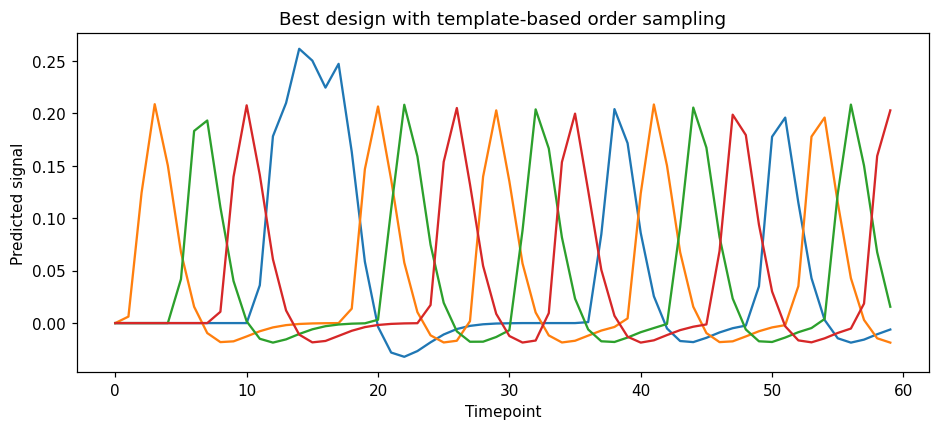

In [4]:
best_design = population.bestdesign
best_design.designmatrix()

best_order = list(best_design.order)
violations = internal_triplet_violations(best_order)

print("Best sampled order:", best_order)
print("Internal 1-2-3 motif violations:", violations)
print("Last 5 events (inspect tail for truncation):", best_order[-5:])
print("Condition counts:", dict(Counter(best_order)))
print(f"Fd (detection efficiency): {best_design.Fd:.4f}")
print(f"Fe (estimation efficiency): {best_design.Fe:.4f}")
print(f"Fc (confounding score): {best_design.Fc:.4f}")
print(f"Ff (frequency-balance score): {best_design.Ff:.4f}")

fig, ax = plt.subplots()
ax.plot(best_design.Xconv)
ax.set_title("Best design with template-based order sampling")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Predicted signal")
plt.show()


## 2. How to read the result

Two checks matter here:

- the interior of the order should show the intended motif structure,
- the tail should be inspected separately because the current implementation truncates the flattened order to `order_length`.

That makes this feature most useful when you want to bias sampling toward recurring local sequences rather than enforce a perfectly complete template decomposition of the entire run.


## 3. Takeaway

Use template-based ordering when the design should be sampled from short event motifs rather than from fully independent event codes. The practical checklist is:

- put the motifs in `order_keys`,
- match their probabilities in `order_probabilities`,
- set `order_length` to the desired event-level length of the final order,
- inspect the tail when templates have different lengths.
